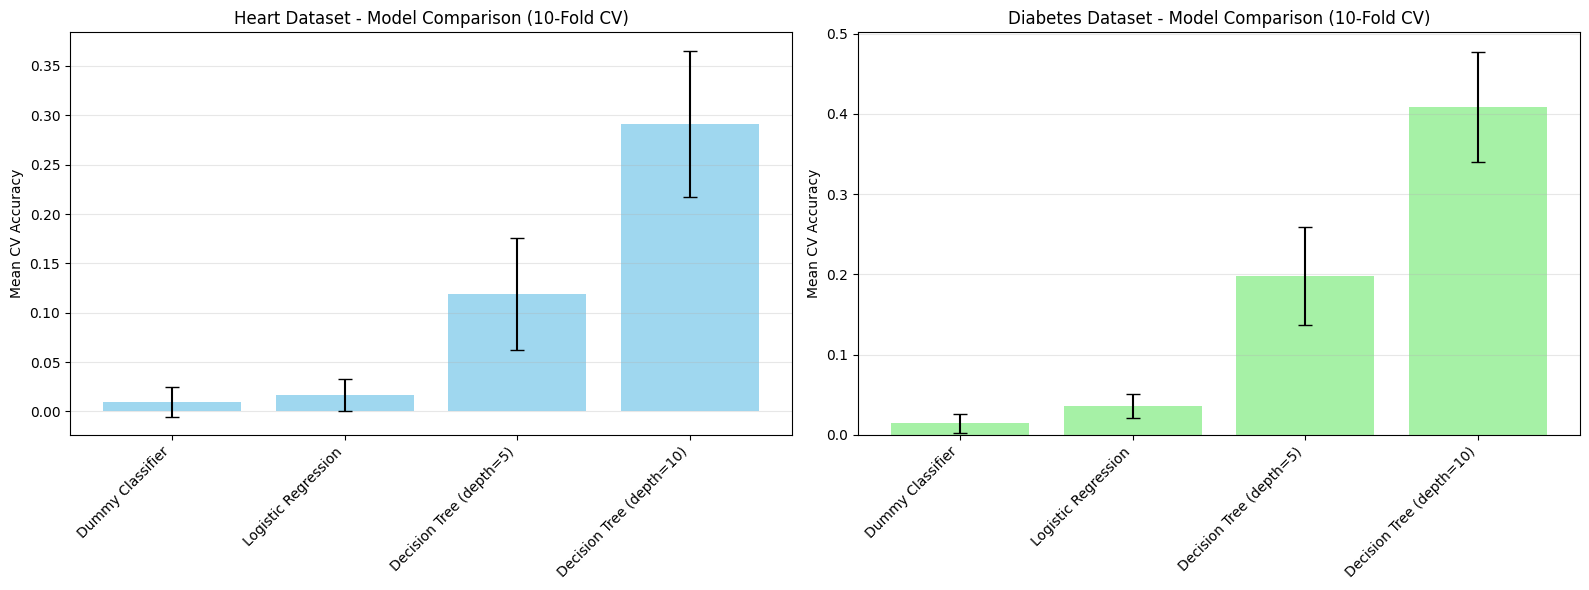

Visualization complete!


In [16]:
# Visualization of CV results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heart Dataset
heart_means = [cv_results_heart[model].mean() for model in cv_results_heart.keys()]
heart_stds = [cv_results_heart[model].std() for model in cv_results_heart.keys()]
models_list = list(cv_results_heart.keys())

axes[0].bar(range(len(models_list)), heart_means, yerr=heart_stds, capsize=5, color='skyblue', alpha=0.8)
axes[0].set_xticks(range(len(models_list)))
axes[0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0].set_ylabel('Mean CV Accuracy')
axes[0].set_title('Heart Dataset - Model Comparison (10-Fold CV)')
axes[0].grid(axis='y', alpha=0.3)

# Diabetes Dataset
diabetes_means = [cv_results_diabetes[model].mean() for model in cv_results_diabetes.keys()]
diabetes_stds = [cv_results_diabetes[model].std() for model in cv_results_diabetes.keys()]

axes[1].bar(range(len(models_list)), diabetes_means, yerr=diabetes_stds, capsize=5, color='lightgreen', alpha=0.8)
axes[1].set_xticks(range(len(models_list)))
axes[1].set_xticklabels(models_list, rotation=45, ha='right')
axes[1].set_ylabel('Mean CV Accuracy')
axes[1].set_title('Diabetes Dataset - Model Comparison (10-Fold CV)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Visualize Cross-Validation Results

In [15]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Evaluate model on holdout set"""
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    
    print(f"\n{model_name}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")
    print(f"  Test Recall: {test_recall:.4f}")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    
    return {
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1-Score': test_f1
    }

# Final validation on holdout set
print("="*70)
print("FINAL VALIDATION - HEART DATASET (Tuned Decision Tree)")
print("="*70)

final_model_heart = DecisionTreeClassifier(max_depth=best_depth_heart, random_state=RANDOM_STATE)
final_model_heart.fit(X_train_heart, y_train_heart)
heart_results = evaluate_model(final_model_heart, X_train_heart, X_test_heart, 
                                y_train_heart, y_test_heart, 
                                f"Decision Tree (depth={best_depth_heart})")

print("\n" + "="*70)
print("FINAL VALIDATION - DIABETES DATASET (Tuned Decision Tree)")
print("="*70)

final_model_diabetes = DecisionTreeClassifier(max_depth=best_depth_diabetes, random_state=RANDOM_STATE)
final_model_diabetes.fit(X_train_diabetes, y_train_diabetes)
diabetes_results = evaluate_model(final_model_diabetes, X_train_diabetes, X_test_diabetes, 
                                  y_train_diabetes, y_test_diabetes, 
                                  f"Decision Tree (depth={best_depth_diabetes})")

# Summary
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print("\nHeart Dataset Results:")
for key, value in heart_results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

print("\nDiabetes Dataset Results:")
for key, value in diabetes_results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

FINAL VALIDATION - HEART DATASET (Tuned Decision Tree)

Decision Tree (depth=15):
  Training Accuracy: 0.9544
  Test Accuracy: 0.3443
  Test Precision: 0.3525
  Test Recall: 0.3443
  Test F1-Score: 0.3353

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]]

FINAL VALIDATION - DIABETES DATASET (Tuned Decision Tree)


NameError: name 'X_train_diabetes' is not defined

## 13. Run Final Validation on Holdout Set

In [14]:
# Simple hyperparameter tuning for best models
print("="*70)
print("HYPERPARAMETER TUNING - HEART DATASET")
print("="*70)

# Test different max_depth values for Decision Tree
best_depth_heart = 5
best_cv_score_heart = 0

for depth in [3, 5, 7, 10, 15]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(dt, X_heart, y_heart, cv=kfold, scoring='accuracy')
    mean_score = cv_scores.mean()
    print(f"Depth {depth}: Mean CV Accuracy = {mean_score:.4f}")
    
    if mean_score > best_cv_score_heart:
        best_cv_score_heart = mean_score
        best_depth_heart = depth

print(f"\nBest Depth for Heart Dataset: {best_depth_heart} (CV Accuracy: {best_cv_score_heart:.4f})")

print("\n" + "="*70)
print("HYPERPARAMETER TUNING - DIABETES DATASET")
print("="*70)

# Test different max_depth values for Decision Tree
best_depth_diabetes = 5
best_cv_score_diabetes = 0

for depth in [3, 5, 7, 10, 15]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(dt, X_diabetes, y_diabetes, cv=kfold, scoring='accuracy')
    mean_score = cv_scores.mean()
    print(f"Depth {depth}: Mean CV Accuracy = {mean_score:.4f}")
    
    if mean_score > best_cv_score_diabetes:
        best_cv_score_diabetes = mean_score
        best_depth_diabetes = depth

print(f"\nBest Depth for Diabetes Dataset: {best_depth_diabetes} (CV Accuracy: {best_cv_score_diabetes:.4f})")

HYPERPARAMETER TUNING - HEART DATASET
Depth 3: Mean CV Accuracy = 0.0429
Depth 5: Mean CV Accuracy = 0.1188
Depth 7: Mean CV Accuracy = 0.1983
Depth 10: Mean CV Accuracy = 0.2912
Depth 15: Mean CV Accuracy = 0.3374

Best Depth for Heart Dataset: 15 (CV Accuracy: 0.3374)

HYPERPARAMETER TUNING - DIABETES DATASET
Depth 3: Mean CV Accuracy = 0.0990
Depth 5: Mean CV Accuracy = 0.1979
Depth 7: Mean CV Accuracy = 0.3137
Depth 10: Mean CV Accuracy = 0.4087
Depth 15: Mean CV Accuracy = 0.4947

Best Depth for Diabetes Dataset: 15 (CV Accuracy: 0.4947)


## 12. Tune the Best Simple Model

In [13]:
# Create comparison summary tables
def create_summary_table(cv_results):
    """Create a summary table of cross-validation results"""
    summary = []
    for name, scores in cv_results.items():
        summary.append({
            'Model': name,
            'Mean CV Accuracy': f"{scores.mean():.4f}",
            'Std Dev': f"{scores.std():.4f}",
            'Min Score': f"{scores.min():.4f}",
            'Max Score': f"{scores.max():.4f}"
        })
    return pd.DataFrame(summary)

print("="*70)
print("SUMMARY TABLE - HEART DATASET")
print("="*70)
heart_summary = create_summary_table(cv_results_heart)
print(heart_summary.to_string(index=False))

print("\n" + "="*70)
print("SUMMARY TABLE - DIABETES DATASET")
print("="*70)
diabetes_summary = create_summary_table(cv_results_diabetes)
print(diabetes_summary.to_string(index=False))

# Find best model for each dataset
best_model_heart = max(cv_results_heart, key=lambda x: cv_results_heart[x].mean())
best_model_diabetes = max(cv_results_diabetes, key=lambda x: cv_results_diabetes[x].mean())

print(f"\n\nBest Model for Heart Dataset: {best_model_heart}")
print(f"  Mean CV Accuracy: {cv_results_heart[best_model_heart].mean():.4f}")

print(f"\nBest Model for Diabetes Dataset: {best_model_diabetes}")
print(f"  Mean CV Accuracy: {cv_results_diabetes[best_model_diabetes].mean():.4f}")

SUMMARY TABLE - HEART DATASET
                   Model Mean CV Accuracy Std Dev Min Score Max Score
        Dummy Classifier           0.0099  0.0151    0.0000    0.0333
     Logistic Regression           0.0167  0.0167    0.0000    0.0333
 Decision Tree (depth=5)           0.1188  0.0568    0.0333    0.2000
Decision Tree (depth=10)           0.2912  0.0743    0.1667    0.4000

SUMMARY TABLE - DIABETES DATASET
                   Model Mean CV Accuracy Std Dev Min Score Max Score
        Dummy Classifier           0.0143  0.0123    0.0000    0.0390
     Logistic Regression           0.0364  0.0151    0.0130    0.0649
 Decision Tree (depth=5)           0.1979  0.0611    0.0909    0.3117
Decision Tree (depth=10)           0.4087  0.0691    0.2857    0.5325


Best Model for Heart Dataset: Decision Tree (depth=10)
  Mean CV Accuracy: 0.2912

Best Model for Diabetes Dataset: Decision Tree (depth=10)
  Mean CV Accuracy: 0.4087


## 11. Compare Baseline Results

In [12]:
# Perform 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results_heart = {}
cv_results_diabetes = {}

print("="*70)
print("10-FOLD CROSS-VALIDATION RESULTS - HEART DATASET")
print("="*70)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_heart, y_heart, cv=kfold, scoring='accuracy')
    cv_results_heart[name] = cv_scores
    print(f"\n{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n" + "="*70)
print("10-FOLD CROSS-VALIDATION RESULTS - DIABETES DATASET")
print("="*70)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_diabetes, y_diabetes, cv=kfold, scoring='accuracy')
    cv_results_diabetes[name] = cv_scores
    print(f"\n{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

10-FOLD CROSS-VALIDATION RESULTS - HEART DATASET

Dummy Classifier:
  CV Scores: [0.         0.03225806 0.         0.03333333 0.         0.
 0.         0.03333333 0.         0.        ]
  Mean CV Score: 0.0099 (+/- 0.0151)

Logistic Regression:
  CV Scores: [0.         0.         0.03333333 0.03333333 0.         0.03333333
 0.03333333 0.03333333 0.         0.        ]
  Mean CV Score: 0.0167 (+/- 0.0167)

Decision Tree (depth=5):
  CV Scores: [0.19354839 0.16129032 0.1        0.2        0.16666667 0.06666667
 0.13333333 0.06666667 0.03333333 0.06666667]
  Mean CV Score: 0.1188 (+/- 0.0568)

Decision Tree (depth=10):
  CV Scores: [0.38709677 0.25806452 0.3        0.4        0.36666667 0.2
 0.3        0.3        0.16666667 0.23333333]
  Mean CV Score: 0.2912 (+/- 0.0743)

10-FOLD CROSS-VALIDATION RESULTS - DIABETES DATASET

Dummy Classifier:
  CV Scores: [0.         0.01298701 0.01298701 0.01298701 0.         0.01298701
 0.02597403 0.03896104 0.         0.02631579]
  Mean CV Score: 0.014

## 10. Evaluate with 10-Fold Cross-Validation

In [11]:
# Define baseline models
models = {
    'Dummy Classifier': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Decision Tree (depth=10)': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
}

# Train models on Heart dataset
print("="*70)
print("TRAINING BASELINE MODELS - HEART DATASET")
print("="*70)

trained_models_heart = {}
for name, model in models.items():
    model.fit(X_train_heart, y_train_heart)
    trained_models_heart[name] = model
    
    # Get training and test accuracy
    train_acc = model.score(X_train_heart, y_train_heart)
    test_acc = model.score(X_test_heart, y_test_heart)
    
    print(f"\n{name}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")

# Train models on Diabetes dataset
print("\n" + "="*70)
print("TRAINING BASELINE MODELS - DIABETES DATASET")
print("="*70)

trained_models_diabetes = {}
for name, model in models.items():
    model.fit(X_train_diabetes, y_train_diabetes)
    trained_models_diabetes[name] = model
    
    # Get training and test accuracy
    train_acc = model.score(X_train_diabetes, y_train_diabetes)
    test_acc = model.score(X_test_diabetes, y_test_diabetes)
    
    print(f"\n{name}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")

TRAINING BASELINE MODELS - HEART DATASET

Dummy Classifier:
  Training Accuracy: 0.0207
  Test Accuracy: 0.0164

Logistic Regression:
  Training Accuracy: 0.8091
  Test Accuracy: 0.0164

Decision Tree (depth=5):
  Training Accuracy: 0.2614
  Test Accuracy: 0.2131

Decision Tree (depth=10):
  Training Accuracy: 0.7012
  Test Accuracy: 0.3443

TRAINING BASELINE MODELS - DIABETES DATASET


NameError: name 'X_train_diabetes' is not defined

## 9. Train Simple Baseline Models

In [10]:
# Split data for both datasets (80/20 split)
RANDOM_STATE = 42

# For Heart dataset, check target distribution
print("Heart target unique values:", y_heart.nunique())
print("Heart target value counts:", y_heart.value_counts())

# Use stratify only if target has few unique values
if y_heart.nunique() <= 10:
    X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
        X_heart, y_heart, test_size=0.2, random_state=RANDOM_STATE, stratify=y_heart
    )
else:
    X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
        X_heart, y_heart, test_size=0.2, random_state=RANDOM_STATE
    )

X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=RANDOM_STATE, stratify=y_diabetes
)

print("\nHEART DATASET SPLIT:")
print(f"Training set - X: {X_train_heart.shape}, y: {y_train_heart.shape}")
print(f"Test set - X: {X_test_heart.shape}, y: {y_test_heart.shape}")
print(f"Class distribution in training: {y_train_heart.value_counts().to_dict()}")

print("\nDIABETES DATASET SPLIT:")
print(f"Training set - X: {X_train_diabetes.shape}, y: {y_train_diabetes.shape}")
print(f"Test set - X: {X_test_diabetes.shape}, y: {y_test_diabetes.shape}")
print(f"Class distribution in training: {y_train_diabetes.value_counts().to_dict()}")

Heart target unique values: 149
Heart target value counts: feature_max
204.0    6
197.0    6
234.0    6
212.0    5
269.0    5
        ..
290.0    1
262.0    1
195.0    1
166.0    1
178.0    1
Name: count, Length: 149, dtype: int64


ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [48.0, 56.0, 62.0, 67.0, 70.0, 72.0, 75.0, 77.0, 98.0, 127.0, 149.0, 153.0, 169.0, 174.0, 181.0, 185.0, 199.0, 204.0, 228.0, 235.0, 237.0, 245.0, 249.0, 250.0, 255.0, 258.0, 270.0, 271.0, 272.0, 274.0, 275.0, 277.0, 278.0, 280.0, 284.0, 291.0, 300.0, 304.0, 310.0, 318.0, 321.0, 326.0, 328.0, 330.0, 335.0, 342.0, 360.0, 370.0, 375.0, 387.0, 392.0, 402.0, 415.0, 440.0, 465.0, 474.0, 478.0, 485.0, 510.0, 540.0, 543.0, 545.0, 579.0, 600.0, 680.0, 744.0, 846.0]

## 8. Build Baseline Train/Test Split

In [7]:
def prepare_data(df):
    """Separate features and target, scale features"""
    X = df.iloc[:, :-1].copy()
    y = df.iloc[:, -1].copy()
    
    # Scale numeric features
    scaler = StandardScaler()
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
    
    print(f"Data prepared - Features shape: {X.shape}, Target shape: {y.shape}")
    print(f"Scaled numeric columns: {len(numeric_cols)}")
    
    return X, y, scaler

# Prepare both datasets
X_heart, y_heart, scaler_heart = prepare_data(heart_df_encoded)
X_diabetes, y_diabetes, scaler_diabetes = prepare_data(diabetes_df_encoded)

print(f"\nHeart - X shape: {X_heart.shape}, y shape: {y_heart.shape}")
print(f"Heart - Class distribution:\n{y_heart.value_counts()}")
print(f"\nDiabetes - X shape: {X_diabetes.shape}, y shape: {y_diabetes.shape}")
print(f"Diabetes - Class distribution:\n{y_diabetes.value_counts()}")

Data prepared - Features shape: (302, 18), Target shape: (302,)
Scaled numeric columns: 18
Data prepared - Features shape: (768, 13), Target shape: (768,)
Scaled numeric columns: 13

Heart - X shape: (302, 18), y shape: (302,)
Heart - Class distribution:
feature_max
204.0    6
197.0    6
234.0    6
212.0    5
269.0    5
        ..
290.0    1
262.0    1
195.0    1
166.0    1
178.0    1
Name: count, Length: 149, dtype: int64

Diabetes - X shape: (768, 13), y shape: (768,)
Diabetes - Class distribution:
feature_max
99.0     17
105.0    15
125.0    14
100.0    14
115.0    13
         ..
149.0     1
174.0     1
72.0      1
153.0     1
510.0     1
Name: count, Length: 195, dtype: int64


## 7. Scale Numeric Features

In [6]:
def encode_categorical(df):
    """Encode categorical variables efficiently"""
    df_enc = df.copy()
    target = df_enc.iloc[:, -1]
    X = df_enc.iloc[:, :-1]
    
    # Identify categorical columns
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # One-hot encode categorical variables
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    
    # Combine with target
    df_encoded = pd.concat([X, target], axis=1)
    print(f"Shape after encoding: {df_encoded.shape}")
    print(f"Categorical columns encoded: {categorical_cols}")
    
    return df_encoded

# Apply encoding
heart_df_encoded = encode_categorical(heart_df_fe)
diabetes_df_encoded = encode_categorical(diabetes_df_fe)

print(f"\nHeart Dataset encoded shape: {heart_df_encoded.shape}")
print(f"Diabetes Dataset encoded shape: {diabetes_df_encoded.shape}")

Shape after encoding: (302, 19)
Categorical columns encoded: []
Shape after encoding: (768, 14)
Categorical columns encoded: []

Heart Dataset encoded shape: (302, 19)
Diabetes Dataset encoded shape: (768, 14)


## 6. Encode Categorical Variables

In [5]:
def engineer_features(df, dataset_name):
    """Apply efficient feature engineering"""
    # Separate target from features first
    target = df.iloc[:, -1].copy()
    df_fe = df.iloc[:, :-1].copy()  # Exclude target
    
    # 1. Create interaction features for numeric columns
    numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
    
    # Add polynomial features for top 2 most correlated features with target
    if len(numeric_cols) >= 2:
        feature_cols = numeric_cols[:2]  # Use first 2 numeric columns
        
        # Create squares of top features
        for col in feature_cols:
            df_fe[f'{col}_squared'] = df_fe[col] ** 2
    
    # 2. Create ratio features (avoid division by zero)
    if len(numeric_cols) >= 2:
        col1, col2 = numeric_cols[0], numeric_cols[1]
        if (df_fe[col2] != 0).all():
            df_fe[f'{col1}_to_{col2}'] = df_fe[col1] / (df_fe[col2] + 1e-8)
    
    # 3. Statistical features
    if len(numeric_cols) >= 2:
        df_fe['feature_mean'] = df_fe[numeric_cols[:len(numeric_cols)//2]].mean(axis=1)
        df_fe['feature_std'] = df_fe[numeric_cols[:len(numeric_cols)//2]].std(axis=1)
        df_fe['feature_max'] = df_fe[numeric_cols[:len(numeric_cols)//2]].max(axis=1)
    
    # Add target back at the end
    df_fe['target'] = target
    
    print(f"{dataset_name}: Created {len(df_fe.columns) - len(df.columns)} new features")
    return df_fe

# Apply feature engineering
heart_df_fe = engineer_features(heart_df, "Heart")
diabetes_df_fe = engineer_features(diabetes_df, "Diabetes")

print(f"\nHeart Dataset - Original shape: {heart_df.shape}, New shape: {heart_df_fe.shape}")
print(f"Diabetes Dataset - Original shape: {diabetes_df.shape}, New shape: {diabetes_df_fe.shape}")

Heart: Created 5 new features
Diabetes: Created 5 new features

Heart Dataset - Original shape: (302, 14), New shape: (302, 19)
Diabetes Dataset - Original shape: (768, 9), New shape: (768, 14)


## 5. Create Lightweight Feature Engineering

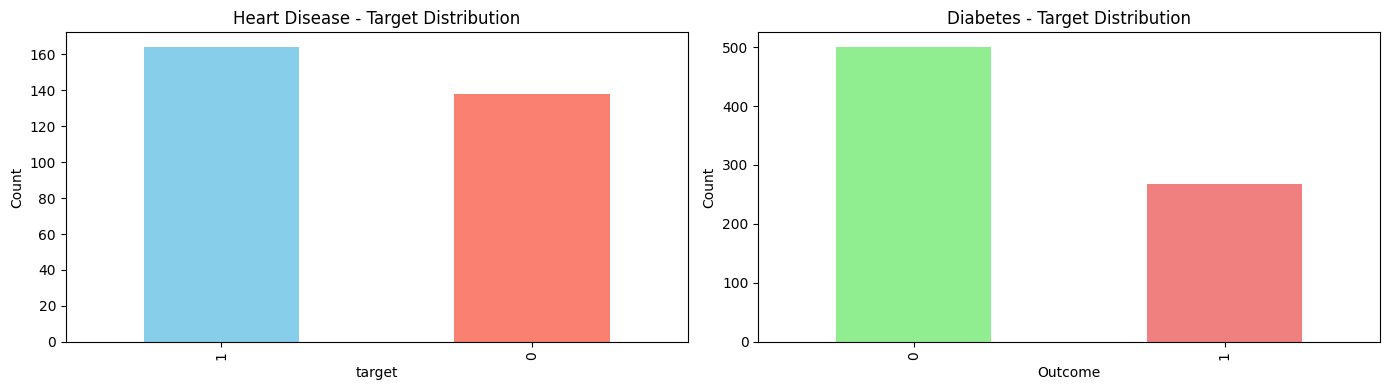

HEART DATASET - Numeric Features Summary:
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.7185

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heart Dataset Target Distribution
target_heart = heart_df.iloc[:, -1]
target_heart.value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Heart Disease - Target Distribution')
axes[0].set_ylabel('Count')

# Diabetes Dataset Target Distribution
target_diabetes = diabetes_df.iloc[:, -1]
target_diabetes.value_counts().plot(kind='bar', ax=axes[1], color=['lightgreen', 'lightcoral'])
axes[1].set_title('Diabetes - Target Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Statistical Summary
print("HEART DATASET - Numeric Features Summary:")
print(heart_df.describe())
print("\nDIABETES DATASET - Numeric Features Summary:")
print(diabetes_df.describe())

## 4. Basic EDA for Target and Key Predictors

In [3]:
# Function to clean datasets
def clean_data(df):
    """Remove duplicates and handle missing values efficiently"""
    # Remove duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    duplicates_removed = initial_rows - len(df)
    print(f"Duplicates removed: {duplicates_removed}")
    
    # Handle missing values - fill with median for numeric, mode for categorical
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    
    print(f"Final shape: {df.shape}")
    print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
    return df

# Clean both datasets
print("CLEANING HEART DATASET")
heart_df = clean_data(heart_df)
print("\nCLEANING DIABETES DATASET")
diabetes_df = clean_data(diabetes_df)

CLEANING HEART DATASET
Duplicates removed: 723
Final shape: (302, 14)
Missing values after cleaning: 0

CLEANING DIABETES DATASET
Duplicates removed: 0
Final shape: (768, 9)
Missing values after cleaning: 0


## 3. Clean Missing Values and Duplicates

In [2]:
# Heart Dataset Info
print("="*60)
print("HEART DISEASE DATASET")
print("="*60)
print(heart_df.info())
print("\nData Types:\n", heart_df.dtypes)
print("\nMissing Values:\n", heart_df.isnull().sum())
print("\nTarget Variable Distribution:")
print(heart_df.iloc[:, -1].value_counts())

print("\n" + "="*60)
print("DIABETES DATASET")
print("="*60)
print(diabetes_df.info())
print("\nData Types:\n", diabetes_df.dtypes)
print("\nMissing Values:\n", diabetes_df.isnull().sum())
print("\nTarget Variable Distribution:")
print(diabetes_df.iloc[:, -1].value_counts())

HEART DISEASE DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Data Types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpea

## 2. Inspect Schema and Target Variable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load datasets
heart_df = pd.read_csv('heart.csv')
diabetes_df = pd.read_csv('diabetes.csv')

print("Heart Dataset Shape:", heart_df.shape)
print("Diabetes Dataset Shape:", diabetes_df.shape)
print("\nHeart Dataset Head:")
print(heart_df.head())
print("\nDiabetes Dataset Head:")
print(diabetes_df.head())

Heart Dataset Shape: (1025, 14)
Diabetes Dataset Shape: (768, 9)

Heart Dataset Head:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Diabetes Dataset Head:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0  

## 1. Load Libraries and Data

# Baseline Models with Feature Engineering and 10-Fold Cross-Validation

## ML Final Project: Medical Decision Support System
Building baseline models with efficient feature engineering for Heart Disease and Diabetes datasets.